In [ ]:
! pip install opendatasets

In [2]:
print("hii")

hii


In [ ]:
import opendatasets as od

In [ ]:
od.download("https://www.kaggle.com/datasets/bryanbradfo/gsoc-deeplense-lens-finding")

In [3]:
import os

base_path = "/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding"

print("Level 1 folders:")
print(os.listdir(base_path))


Level 1 folders:
['train_lenses', 'test_nonlenses', 'train_nonlenses', 'test_lenses']


In [6]:
import os

# Define paths
data_dir = "/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding"

# Define the actual directories found
train_lenses_dir = os.path.join(data_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(data_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def count_files(directory):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return 0
    return len([f for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])

# Calculate total counts for 'substructure' (lenses) and 'no substructure' (non-lenses)
total_substructure_count = count_files(train_lenses_dir) + count_files(test_lenses_dir)
total_no_substructure_count = count_files(train_nonlenses_dir) + count_files(test_nonlenses_dir)

print(f" Substructure Images (total lenses): {total_substructure_count}")
print(f" No Substructure Images (total non-lenses): {total_no_substructure_count}")


 Substructure Images (total lenses): 1925
 No Substructure Images (total non-lenses): 48130


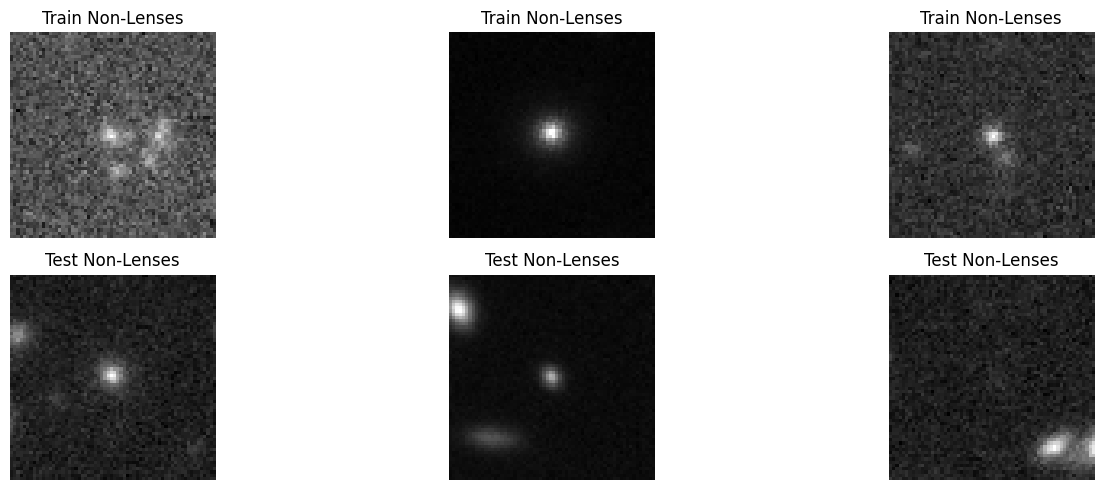

In [7]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np

# Define paths (from previous execution)
data_dir = '/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding'

train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def get_sample_images(directory, num_samples=3):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return []
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    return random.sample(all_files, min(num_samples, len(all_files)))

# Get sample images from each category for non-lenses
sample_train_nonlenses = get_sample_images(train_nonlenses_dir)
sample_test_nonlenses = get_sample_images(test_nonlenses_dir)

# Only include 'non-lenses' categories for display
all_samples = {
    'Train Non-Lenses': sample_train_nonlenses,
    'Test Non-Lenses': sample_test_nonlenses
}

plt.figure(figsize=(15, 5)) # Adjust figure size for fewer categories
plot_index = 1

for category, paths in all_samples.items():
    for img_path in paths:
        if os.path.exists(img_path):
            plt.subplot(len(all_samples), len(paths), plot_index)
            try:
                img_array = np.load(img_path)
                # Transpose the array from (channels, height, width) to (height, width, channels)
                if img_array.shape[0] == 3 and len(img_array.shape) == 3: # Check if it's (3, H, W)
                    img_array = np.transpose(img_array, (1, 2, 0)) # Change to (H, W, 3)

                # If it's still 3 channels but needs to be displayed as grayscale, take the mean across channels
                if img_array.shape[-1] == 3 and len(img_array.shape) == 3:
                    img_array = img_array.mean(axis=-1) # Take mean across channels for grayscale display

                plt.imshow(img_array, cmap='gray') # Display the numpy array, assuming grayscale
                plt.title(f"{category}")
                plt.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Error loading or displaying {img_path}: {e}")
        else:
            print(f"Could not find image: {img_path}")

plt.tight_layout()
plt.show()


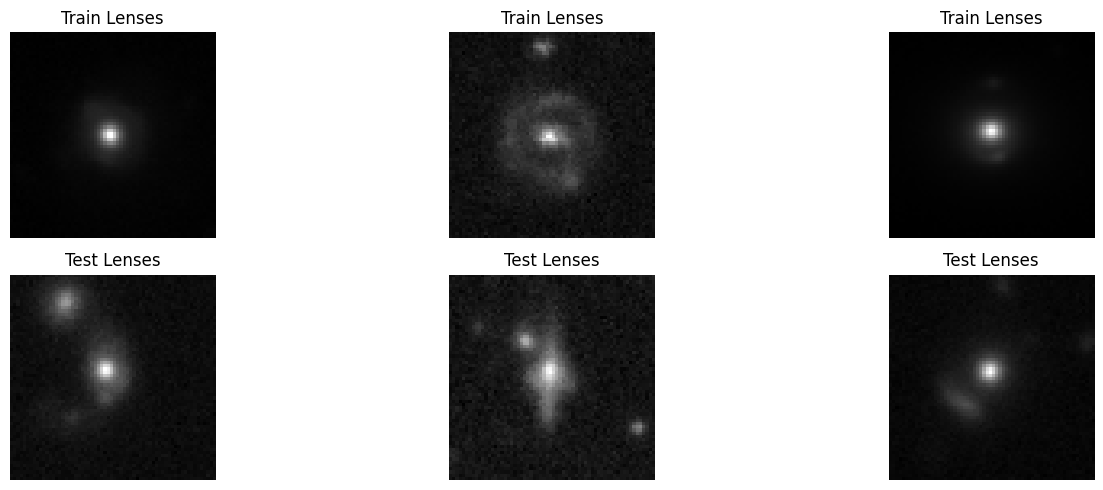

In [8]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np # Import numpy to handle .npy files

# Define paths (from previous execution)
data_dir = '/kaggle/input/datasets/bryanbradfo/gsoc-deeplense-lens-finding'

train_lenses_dir = os.path.join(data_dir, 'train_lenses')
train_nonlenses_dir = os.path.join(data_dir, 'train_nonlenses')
test_lenses_dir = os.path.join(data_dir, 'test_lenses')
test_nonlenses_dir = os.path.join(data_dir, 'test_nonlenses')

def get_sample_images(directory, num_samples=3):
    if not os.path.isdir(directory):
        print(f"Warning: Directory not found: {directory}")
        return []
    all_files = [os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))]
    return random.sample(all_files, min(num_samples, len(all_files)))

# Get sample images from each category
sample_train_lenses = get_sample_images(train_lenses_dir)
sample_test_lenses = get_sample_images(test_lenses_dir)

# Only include 'lenses' categories for display
all_samples = {
    'Train Lenses': sample_train_lenses,
    'Test Lenses': sample_test_lenses
}

plt.figure(figsize=(15, 5)) # Adjust figure size for fewer categories
plot_index = 1

for category, paths in all_samples.items():
    for img_path in paths:
        if os.path.exists(img_path):
            plt.subplot(len(all_samples), len(paths), plot_index)
            try:
                img_array = np.load(img_path)
                # Transpose the array from (channels, height, width) to (height, width, channels)
                if img_array.shape[0] == 3 and len(img_array.shape) == 3: # Check if it's (3, H, W)
                    img_array = np.transpose(img_array, (1, 2, 0)) # Change to (H, W, 3)

                # If it's still 3 channels but needs to be displayed as grayscale, take the mean across channels
                if img_array.shape[-1] == 3 and len(img_array.shape) == 3:
                    img_array = img_array.mean(axis=-1) # Take mean across channels for grayscale display

                plt.imshow(img_array, cmap='gray') # Display the numpy array, assuming grayscale
                plt.title(f"{category}")
                plt.axis('off')
                plot_index += 1
            except Exception as e:
                print(f"Error loading or displaying {img_path}: {e}")
        else:
            print(f"Could not find image: {img_path}")

plt.tight_layout()
plt.show()


In [9]:
lenses_paths = []
for directory in [train_lenses_dir, test_lenses_dir]:
    if os.path.isdir(directory):
        lenses_paths.extend([os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    else:
        print(f"Warning: Directory not found: {directory}")

non_lenses_paths = []
for directory in [train_nonlenses_dir, test_nonlenses_dir]:
    if os.path.isdir(directory):
        non_lenses_paths.extend([os.path.join(directory, f) for f in os.listdir(directory) if os.path.isfile(os.path.join(directory, f))])
    else:
        print(f"Warning: Directory not found: {directory}")

print(f"Total lenses images found: {len(lenses_paths)}")
print(f"Total non-lenses images found: {len(non_lenses_paths)}")

Total lenses images found: 1925
Total non-lenses images found: 48130


In [10]:
all_paths = lenses_paths + non_lenses_paths
all_labels = [1] * len(lenses_paths) + [0] * len(non_lenses_paths)

print(f"Total images in combined dataset: {len(all_paths)}")
print(f"Total lenses images in combined dataset: {sum(all_labels)}")
print(f"Total non-lenses images in combined dataset: {len(all_labels) - sum(all_labels)}")

Total images in combined dataset: 50055
Total lenses images in combined dataset: 1925
Total non-lenses images in combined dataset: 48130


In [11]:
from sklearn.model_selection import train_test_split

# Split the data into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(
    all_paths,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=42
)

print(f"Training set - Lenses: {sum(y_train)}, Non-lenses: {len(y_train) - sum(y_train)}")
print(f"Validation set - Lenses: {sum(y_val)}, Non-lenses: {len(y_val) - sum(y_val)}")


Training set - Lenses: 1540, Non-lenses: 38504
Validation set - Lenses: 385, Non-lenses: 9626


***PARAMETERS***

In [12]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import random
import os

2026-02-20 06:25:26.970109: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771568727.196026      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771568727.264570      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771568727.789533      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771568727.789584      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771568727.789587      55 computation_placer.cc:177] computation placer alr

In [16]:
#setting the seed
SEED = 42
keras.utils.set_random_seed(SEED)

#hyperparameters
BUFFER_SIZE = 1224 # how many imgs are we shuffling at once
BATCH_SIZE = 256 # how many imgs are we loading at once
AUTO = tf.data.AUTOTUNE # how many threads to use for prefetching
INPUT_SHAPE = (32,32,3)
NUM_CLASS = 100

LEARNING_RATE = 3e-4
WEIGHT_DECAY = 0.001 #Penalty to prevent overfitting (memorizing instead of learning)
EPOCHS = 250
IMAGE_SIZE = 48
PATCH_SIZE = 4
NUM_PATCHES = (IMAGE_SIZE // PATCH_SIZE) ** 2
MASK_PROPORTION = 0.90

ENC_PROJ_DIM = 192 #PROJECTION_DIM = How many numbers represent each patch
DEC_PROJ_DIM = 96 #Decoder uses 96 (was 64, changed to match definition in decoder cell)
ENC_NUM_HEADS = 8 #NUM_HEADS = Attention heads (AI looks at image in 4 different ways simultaneously)
ENC_LAYERS = 10 #LAYERS = Stack 6 transformer blocks on top of each other (deeper = more learning)
LAYER_NORM_EPS = 1e-6
DEC_NUM_HEADS = 4
DEC_LAYERS = 6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]

DEC_TRANSFORMER_UNITS = [
    DEC_PROJ_DIM * 4,
    DEC_PROJ_DIM,
]

PATCH_AREA = PATCH_SIZE * PATCH_SIZE * 3 # Calculate once, globally

In [14]:
# ========================================
# FIXED PREPROCESSING - NO MORE ERRORS!
# ========================================

def load_and_preprocess_image(image_path):
    """
    Load .npy file and convert to (48, 48, 3) normalized image
    FIXED for TensorFlow graph mode!
    """
    # Load .npy file
    def load_npy(path):
        img = np.load(path.numpy().decode('utf-8'))
        return img.astype(np.float32)
    
    image = tf.py_function(load_npy, [image_path], tf.float32)
    
    # CRITICAL: Set shape to help TensorFlow
    image.set_shape([None, None, None])
    
    # Get current shape
    current_shape = tf.shape(image)
    ndim = len(image.shape)
    
    # Case 1: 2D image (H, W) -> add channel dimension
    if ndim == 2 or (ndim == 3 and image.shape[-1] is None):
        image = tf.cond(
            tf.equal(tf.size(current_shape), 2),
            lambda: tf.expand_dims(image, axis=-1),
            lambda: image
        )
        current_shape = tf.shape(image)
    
    # Case 2: (C, H, W) -> (H, W, C) - check if first dim is 3
    def maybe_transpose():
        return tf.transpose(image, [1, 2, 0])
    
    def keep_as_is():
        return image
    
    # Only transpose if shape[0] == 3 and shape[1] > 3
    should_transpose = tf.logical_and(
        tf.equal(current_shape[0], 3),
        tf.greater(current_shape[1], 3)
    )
    image = tf.cond(should_transpose, maybe_transpose, keep_as_is)
    
    # Update shape
    current_shape = tf.shape(image)
    
    # Case 3: Grayscale (H, W, 1) -> (H, W, 3)
    def tile_channels():
        return tf.tile(image, [1, 1, 3])
    
    def keep_rgb():
        return image
    
    # Check if last dimension is 1
    is_grayscale = tf.equal(current_shape[-1], 1)
    image = tf.cond(is_grayscale, tile_channels, keep_rgb)
    
    # Resize to target size
    image = tf.image.resize(image, [IMAGE_SIZE, IMAGE_SIZE])
    
    # Normalize to [0, 1]
    image_min = tf.reduce_min(image)
    image_max = tf.reduce_max(image)
    image = (image - image_min) / (image_max - image_min + 1e-8)
    
    # Clip to ensure range
    image = tf.clip_by_value(image, 0.0, 1.0)
    
    # Set final shape explicitly
    image.set_shape([IMAGE_SIZE, IMAGE_SIZE, 3])
    
    return image

print("✅ Fixed preprocessing function loaded!")

✅ Fixed preprocessing function loaded!


***PATCH LAYER***

In [17]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import random
import os


In [18]:
#cutting images into pieces
class Patches(layers.Layer):
  def __init__(self, patch_size = PATCH_SIZE, **kwargs):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.resize = layers.Reshape((-1, patch_size* patch_size * 3))
  # -1 = "figure out this dimension automatically"
# patch_size * patch_size * 3 = 6×6×3 = 108 numbers per patch

  # this func cuts images into non overlapping 6x6 squares
  def call(self, images):
    patches = tf.image.extract_patches(
        images = images,
        sizes = [1, self.patch_size , self.patch_size, 1],#sizes = [batch, height, width, channels] → extract 6×6 patches
        strides = [1, self.patch_size, self.patch_size, 1],#strides = how far to move between patches (6 = no overlap)
        rates = [1, 1, 1, 1],
        padding = "VALID", # means font add extra padding
    )
    patches = self.resize(patches)
    return patches

#this func takes a batch of imgs and helps visualize one image and
# its patches side by side
  def show_patched_image(self, images, patches):
    idx = np.random.choice(patches.shape[0])
    print(f"index selected : {idx}")
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI
    plt.imshow(keras.utils.array_to_img(images[idx]))
    plt.axis("off")
    plt.title("Original Augmented Image")
    plt.show()

    n = int(np.sqrt(patches.shape[1]))
    plt.figure(figsize = (5,5), dpi=100) # Consistent figure size and DPI for the grid
    for i, patch_tensor in enumerate(patches[idx]):
      ax = plt.subplot(n, n, i+1)
      reshaped_patch = tf.reshape(patch_tensor, (self.patch_size, self.patch_size, 3)).numpy()
      ax.imshow(reshaped_patch)
      ax.axis("off")
    plt.suptitle("Individual Patches")
    plt.show()
    return idx

  # this func reconstructs the img by joining the patches
  def reconstruct_from_patch(self,patch):
    num_patches = patch.shape[0]
    n = int(np.sqrt(num_patches))

    #Reshape the flattened patches to their original (patch_size, patch_size, 3) shape
    individual_patches = tf.reshape(patch, (num_patches, self.patch_size, self.patch_size, 3))

    # Arrange the individual patches into an n x n grid
    patches_grid = tf.reshape(individual_patches, (n, n, self.patch_size, self.patch_size, 3))

    # Transpose and reshape to combine patches into a single image
    reconstructed = tf.reshape(
        tf.transpose(patches_grid, perm=[0, 2, 1, 3, 4]),
        [n * self.patch_size, n * self.patch_size, 3]
    )
    return reconstructed

***PATCH ENCODER***

In [19]:
from keras import layers

# Temporarily defining parameters here for execution, should ideally be run from parameter cell
PATCH_SIZE = 4
ENC_PROJ_DIM = 192
MASK_PROPORTION = 0.90

class PatchEncoder(layers.Layer):
  def __init__(
      self,
      patch_size = PATCH_SIZE,
      projection_dim = ENC_PROJ_DIM,
      mask_proportion = MASK_PROPORTION,
      downstream = False,
      **kwargs
  ):
    super().__init__(**kwargs)
    self.patch_size = patch_size
    self.projection_dim = projection_dim
    self.mask_proportion = mask_proportion
    self.downstream = downstream


    # mask the token now hehehe
    self.mask_token = tf.Variable(
        tf.random.normal([1, patch_size * patch_size * 3]),
        trainable = True,
    ) # this token will learn how the hidden patches look like

  def build(self, input_shape):
    (_, self.num_patches, self.patch_area) = input_shape

    # Create the projection layer for the patches
    self.projection = layers.Dense(units = self.projection_dim)

    # create positional embedding layer
    self.position_embedding = layers.Embedding(
        input_dim = self.num_patches,
        output_dim = self.projection_dim,
    )

    # num of patches itll mask
    self.num_mask = int(self.mask_proportion * self.num_patches)

  def call(self, patches):
    #gets the positional embeddings
    batch_size = tf.shape(patches)[0]
    positions = tf.range(start=0, limit=self.num_patches, delta = 1)
    pos_embeddings = self.position_embedding(positions[tf.newaxis,...])
    pos_embeddings = tf.tile(
        pos_embeddings, [batch_size, 1, 1]
    )

    # embedd the patches
    patch_embeddings = (
        self.projection(patches) + pos_embeddings
    )

    if self.downstream:
      return patch_embeddings

    else:
      mask_indices, unmask_indices = self.get_random_indices(batch_size)
      # selects random patches from batch and mask some and keep some unmasked

      # gathers the unmasked patches that'll be sent into the ENC
      unmasked_embeddings = tf.gather(
          patch_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      #gets the masked and unmasked position embeddings

      unmasked_positions = tf.gather(
          pos_embeddings,
          unmask_indices, axis = 1,
          batch_dims = 1,
      )

      mask_positions = tf.gather(
          pos_embeddings,
          mask_indices,
          axis = 1,
          batch_dims = 1,
      )

      mask_tokens = tf.repeat(self.mask_token, repeats = self.num_mask, axis = 0)
      mask_tokens = tf.repeat(
          mask_tokens[tf.newaxis, ...],
          repeats = batch_size,
          axis = 0
      )

      # creats mask embeddings for the masked tokens
      mask_embeddings = self.projection(mask_tokens) + mask_positions
                             # content of the patch + position of the patch
      return(
          unmasked_embeddings, # sent to rnc
          mask_embeddings, # sent to dec
          unmasked_positions, # sent to dec
          mask_indices, #dec
          unmask_indices, # dec
      )

  def get_random_indices(self, batch_size):
        # Create random indices from a uniform distribution and then split
        # it into mask and unmask indices.
        rand_indices = tf.argsort(
            tf.random.uniform(shape=(batch_size, self.num_patches)), axis=-1
        )
        mask_indices = rand_indices[:, : self.num_mask]
        unmask_indices = rand_indices[:, self.num_mask :]
        return mask_indices, unmask_indices

  def generate_masked_image(self, patches, unmask_indices):
        # Choose a random patch and it corresponding unmask index.
        idx = np.random.choice(patches.shape[0])
        patch = patches[idx]
        unmask_index = unmask_indices[idx]

        # Build a numpy array of same shape as patch.
        new_patch = np.zeros_like(patch)

        # Iterate of the new_patch and plug the unmasked patches.
        count = 0
        for i in range(unmask_index.shape[0]):
            new_patch[unmask_index[i]] = patch[unmask_index[i]]
        return new_patch, idx

I0000 00:00:1771568782.411629      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1771568782.417510      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


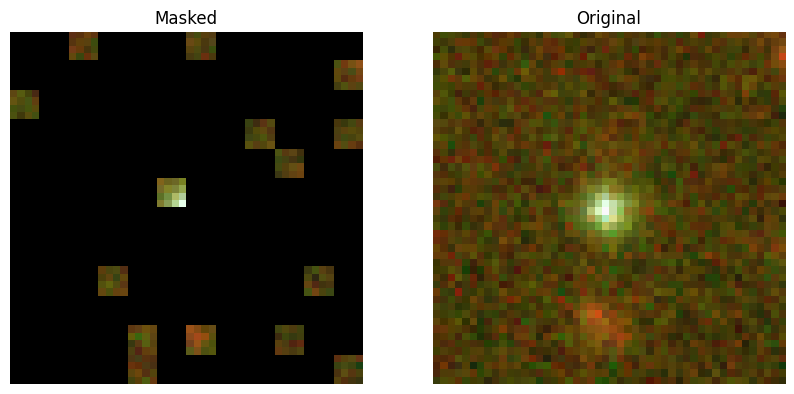

In [20]:
# Create the patch encoder layer.
patch_encoder = PatchEncoder()

# Instantiate Patches layer
patch_layer = Patches(patch_size=PATCH_SIZE)

# Load a sample image
sample_image_path = X_train[0] # Taking one image path from the training set
original_image = np.load(sample_image_path)

# Preprocess the image: Ensure it's (H, W, C) and resize to IMAGE_SIZE
# The original image data might be (C, H, W), so transpose if necessary.
if original_image.shape[0] == 3 and len(original_image.shape) == 3:
    original_image = np.transpose(original_image, (1, 2, 0))

# Convert to tf.float32 for tf.image.resize and normalize if needed.
# Assuming images are already normalized or scaling is handled by tf.image.resize or keras.utils.array_to_img
original_image = tf.image.resize(tf.convert_to_tensor(original_image, dtype=tf.float32), (IMAGE_SIZE, IMAGE_SIZE))

# Ensure 3 channels. If it's grayscale (H, W) or (H, W, 1), convert to (H, W, 3).
if len(original_image.shape) == 2: # (H, W)
    original_image = tf.expand_dims(original_image, axis=-1) # -> (H, W, 1)
    original_image = tf.repeat(original_image, repeats=3, axis=-1) # -> (H, W, 3)
elif original_image.shape[-1] == 1: # (H, W, 1)
    original_image = tf.repeat(original_image, repeats=3, axis=-1) # -> (H, W, 3)

# Add batch dimension: (1, IMAGE_SIZE, IMAGE_SIZE, 3)
augmented_images = tf.expand_dims(original_image, 0)

# Generate patches
patches = patch_layer(augmented_images)


# Get the embeddings and positions.
(
    unmasked_embeddings,
    masked_embeddings,
    unmasked_positions,
    mask_indices,
    unmask_indices,
) = patch_encoder(patches=patches)


# Show a masked patch image.
new_patch, random_index = patch_encoder.generate_masked_image(patches, unmask_indices)

plt.figure(figsize=(10, 10))
plt.subplot(1, 2, 1)
img = patch_layer.reconstruct_from_patch(new_patch)
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Masked")
plt.subplot(1, 2, 2)
img = augmented_images[random_index]
plt.imshow(keras.utils.array_to_img(img))
plt.axis("off")
plt.title("Original")
plt.show()

***MLP***

In [21]:
def mlp(x, dropout_rate, hidden_units):
  for units in hidden_units:
    x = layers.Dense(units, activation=tf.nn.gelu)(x)
    x = layers.Dropout(dropout_rate)(x)
  return x

***MAE ENCODER***

In [22]:
import keras
from keras import layers

ENC_PROECTION_DIM = 192
ENC_NUM_HEADS = 6
ENC_LAYERS = 10
DROPOUT_RATE = 0.1
LAYER_NORM_EPS = 1e-6

ENC_TRANSFORMER_UNITS =[
    ENC_PROJ_DIM * 4,
    ENC_PROJ_DIM,
]


def create_encoder():
  inputs = layers.Input(shape = (None, ENC_PROJ_DIM))
  x = inputs

  for _ in range(ENC_LAYERS):

    # 1. layer norm
    x1 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    # 2, attention
    attention_output = layers.MultiHeadAttention(
        num_heads = ENC_NUM_HEADS,
        key_dim = ENC_PROJ_DIM // ENC_NUM_HEADS,
        dropout = DROPOUT_RATE,
    )(x1, x1)

    attention_output = layers.Dropout(DROPOUT_RATE)(attention_output)

    # 3. residual
    x2 = layers.Add()([x, attention_output])

    # 4. layer norm
    x3 = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x2)

    x3 = mlp(x3, hidden_units = ENC_TRANSFORMER_UNITS, dropout_rate = DROPOUT_RATE,)

    x = layers.Add()([x2, x3])

    outputs = layers.LayerNormalization(epsilon = LAYER_NORM_EPS)(x)

    return keras.Model(inputs, outputs, name = "mae_enc_strong")



In [23]:
optimizer = keras.optimizers.AdamW(
    learning_rate=3e-4,
    weight_decay=0.05
)


***DECODER***

In [24]:
import keras
from keras import layers
import tensorflow as tf

# ===============================
# Production-Level Decoder
# ===============================
def create_decoder():

    inputs = layers.Input((NUM_PATCHES, ENC_PROJ_DIM))

    # Project encoder dim → decoder dim
    x = layers.Dense(DEC_PROJ_DIM)(inputs)

    # Positional embedding for decoder
    positions = tf.range(start=0, limit=NUM_PATCHES, delta=1)
    pos_embedding = layers.Embedding(
        input_dim=NUM_PATCHES,
        output_dim=DEC_PROJ_DIM
    )(positions)

    x = x + pos_embedding

    # Transformer blocks
    for _ in range(DEC_LAYERS):

        # Pre-Norm Attention
        x1 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

        attn_output = layers.MultiHeadAttention(
            num_heads=DEC_NUM_HEADS,
            key_dim=DEC_PROJ_DIM // DEC_NUM_HEADS,
            dropout=DROPOUT_RATE,
        )(x1, x1)

        attn_output = layers.Dropout(DROPOUT_RATE)(attn_output)

        x2 = layers.Add()([x, attn_output])

        # Pre-Norm MLP
        x3 = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x2)

        x3 = mlp(
            x3,
            hidden_units=DEC_TRANSFORMER_UNITS,
            dropout_rate=DROPOUT_RATE,
        )

        x = layers.Add()([x2, x3])

    x = layers.LayerNormalization(epsilon=LAYER_NORM_EPS)(x)

    # Reconstruct patches
    patch_outputs = layers.Dense(PATCH_AREA)(x)

    # Convert patches → image
    outputs = layers.Reshape(
        (IMAGE_SIZE // PATCH_SIZE,
         IMAGE_SIZE // PATCH_SIZE,
         PATCH_SIZE,
         PATCH_SIZE,
         3)
    )(patch_outputs)

    outputs = layers.Lambda(lambda x: tf.transpose(x, perm=[0,1,3,2,4,5]))(outputs)
    outputs = layers.Reshape((IMAGE_SIZE, IMAGE_SIZE, 3))(outputs)

    return keras.Model(inputs, outputs, name="mae_decoder_strong")

***MAE TRAINER***

In [25]:
class MaskedAutoencoder(keras.Model):
    def __init__(
        self,
        train_augmentation_model,
        test_augmentation_model,
        patch_layer,
        patch_encoder,
        encoder,
        decoder,
        **kwargs,
    ):
        super().__init__(**kwargs)
        self.train_augmentation_model = train_augmentation_model
        self.test_augmentation_model = test_augmentation_model
        self.patch_layer = patch_layer
        self.patch_encoder = patch_encoder
        self.encoder = encoder
        self.decoder = decoder

    def calculate_loss(self, images, test=False):
        # Augment the input images.
        if test:
            augmented_images = self.test_augmentation_model(images)
        else:
            augmented_images = self.train_augmentation_model(images)

        # Patch the augmented images.
        patches = self.patch_layer(augmented_images)

        # Encode the patches.
        (
            unmasked_embeddings,
            masked_embeddings,
            unmasked_positions,
            mask_indices,
            unmask_indices,
        ) = self.patch_encoder(patches)

        # Pass the unmaksed patche to the encoder.
        encoder_outputs = self.encoder(unmasked_embeddings)

        # Create the decoder inputs.
        encoder_outputs = encoder_outputs + unmasked_positions
        decoder_inputs = tf.concat([encoder_outputs, masked_embeddings], axis=1)

        # Decode the inputs.
        decoder_outputs = self.decoder(decoder_inputs)
        decoder_patches = self.patch_layer(decoder_outputs)

        loss_patch = tf.gather(patches, mask_indices, axis=1, batch_dims=1)
        loss_output = tf.gather(decoder_patches, mask_indices, axis=1, batch_dims=1)

        # Compute the total loss.
        total_loss = self.compute_loss(y=loss_patch, y_pred=loss_output)

        return total_loss, loss_patch, loss_output

    def train_step(self, images):
        with tf.GradientTape() as tape:
            total_loss, loss_patch, loss_output = self.calculate_loss(images)

        # Apply gradients.
        train_vars = [
            self.train_augmentation_model.trainable_variables,
            self.patch_layer.trainable_variables,
            self.patch_encoder.trainable_variables,
            self.encoder.trainable_variables,
            self.decoder.trainable_variables,
        ]
        grads = tape.gradient(total_loss, train_vars)
        tv_list = []
        for grad, var in zip(grads, train_vars):
            for g, v in zip(grad, var):
                tv_list.append((g, v))
        self.optimizer.apply_gradients(tv_list)

        # Report progress.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results

    def test_step(self, images):
        total_loss, loss_patch, loss_output = self.calculate_loss(images, test=True)

        # Update the trackers.
        results = {}
        for metric in self.metrics:
            metric.update_state(loss_patch, loss_output)
            results[metric.name] = metric.result()
        return results


In [26]:
encoder = create_encoder()

***LOADING WEIGHTS***

In [27]:
import os

for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if "mae" in f.lower():
            print(os.path.join(root, f))


/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5
/kaggle/input/models/sqyhu80/maecifar100pretrained/tensorflow2/default/1/mae_encoder_cifar100.weights.h5


In [28]:
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/maecifar100pretrained/tensorflow2/default/1/mae_encoder_cifar100.weights.h5"
)

In [29]:
decoder = create_decoder()

In [30]:
# Define simple placeholder augmentation models
train_augmentation_model = tf.keras.Sequential([tf.keras.layers.Identity()])
test_augmentation_model = tf.keras.Sequential([tf.keras.layers.Identity()])

mae_model = MaskedAutoencoder(
    train_augmentation_model=train_augmentation_model,
    test_augmentation_model=test_augmentation_model,
    encoder=encoder,
    decoder=decoder,
    patch_layer=patch_layer,
    patch_encoder=patch_encoder
)

In [31]:
# Function to load and preprocess a single image
def load_and_preprocess_image(image_path):
    # Load the .npy file. The output shape can vary, so we handle it dynamically.
    image = tf.py_function(lambda x: np.load(x.numpy().decode('utf-8')), [image_path], tf.float32)
    # Initially set shape to ensure rank is known for subsequent tf.shape operations
    image.set_shape([None, None, None]) # Assuming max 3 dimensions (H, W, C or C, H, W)

    # Get dynamic shape information
    current_shape = tf.shape(image)
    current_rank = tf.rank(image)

    # --- Handle 2D images: (H, W) -> (H, W, 1) ---
    def expand_to_3d_fn():
        return tf.expand_dims(image, axis=-1)
    image = tf.cond(tf.equal(current_rank, 2), expand_to_3d_fn, lambda: image)

    # Re-evaluate current_shape after potential expansion to 3D
    current_shape = tf.shape(image)

    # --- Handle (C, H, W) -> (H, W, C) transposition if needed ---
    # Heuristic: if the first dimension is 3 and the other two are much larger,
    # it's likely (C, H, W). Otherwise, assume (H, W, C).
    def transpose_chw_to_hwc_fn(): # No 'img' arg needed if 'image' is captured
        return tf.transpose(image, (1, 2, 0))

    # Only transpose if the first dimension is 3 AND the other two are significantly larger than 3,
    # to avoid transposing (H, W, 3) images mistakenly.
    is_chw_format = tf.logical_and(
        tf.equal(current_shape[0], 3),
        tf.logical_and(tf.greater(current_shape[1], 3), tf.greater(current_shape[2], 3))
    )
    image = tf.cond(is_chw_format, transpose_chw_to_hwc_fn, lambda: image)

    # --- Ensure it has 3 channels ---
    # This part MUST happen BEFORE tf.image.resize if resize expects known channels.
    current_channels = tf.shape(image)[-1]

    def convert_1_to_3_channels_fn():
        return tf.repeat(image, repeats=3, axis=2) # Explicit axis=2 for C

    def convert_many_to_3_channels_fn():
        # Reduce to grayscale (1 channel) then repeat to 3 channels
        grayscale_image = tf.reduce_mean(image, axis=2, keepdims=True) # Explicit axis=2 for C
        return tf.repeat(grayscale_image, repeats=3, axis=2) # Explicit axis=2 for C

    image = tf.cond(tf.equal(current_channels, 1),
                    convert_1_to_3_channels_fn,
                    lambda: tf.cond(tf.greater(current_channels, 3),
                                    convert_many_to_3_channels_fn,
                                    lambda: image)) # Assume it's already 3 channels if not 1 or >3

    # Explicitly set static shape with known channel count after channel conversion.
    # This is crucial for tf.image.resize to infer the rank + channels.
    image.set_shape([None, None, 3])

    # Now, `image` should be (H, W, C) with C=3. Resize it.
    image = tf.image.resize(image, (IMAGE_SIZE, IMAGE_SIZE))

    # Explicitly ensure the final output shape for static graph compatibility
    image = tf.ensure_shape(image, (IMAGE_SIZE, IMAGE_SIZE, 3))
    return image

# Create a tf.data.Dataset for validation images
test_ds = (
    tf.data.Dataset.from_tensor_slices(X_val)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# Taking a batch of test inputs to measure model's progress.
test_images = next(iter(test_ds))


class TrainMonitor(keras.callbacks.Callback):
    def __init__(self, epoch_interval=None):
        self.epoch_interval = epoch_interval

    def on_epoch_end(self, epoch, logs=None):
        if self.epoch_interval and epoch % self.epoch_interval == 0:
            test_augmented_images = self.model.test_augmentation_model(test_images)
            test_patches = self.model.patch_layer(test_augmented_images)
            (
                test_unmasked_embeddings,
                test_masked_embeddings,
                test_unmasked_positions,
                test_mask_indices,
                test_unmask_indices,
            ) = self.model.patch_encoder(test_patches)
            test_encoder_outputs = self.model.encoder(test_unmasked_embeddings)
            test_encoder_outputs = test_encoder_outputs + test_unmasked_positions
            test_decoder_inputs = tf.concat(
                [test_encoder_outputs, test_masked_embeddings], axis=1
            )
            test_decoder_outputs = self.model.decoder(test_decoder_inputs)

            # Show a maksed patch image.
            test_masked_patch, idx = self.model.patch_encoder.generate_masked_image(
                test_patches, test_unmask_indices
            )
            print(f"\nIdx chosen: {idx}")
            original_image = test_augmented_images[idx]
            masked_image = self.model.patch_layer.reconstruct_from_patch(
                test_masked_patch
            )
            reconstructed_image = test_decoder_outputs[idx]

            fig, ax = plt.subplots(nrows=1, ncols=3, figsize=(15, 5))
            ax[0].imshow(original_image)
            ax[0].set_title(f"Original: {epoch:03d}")

            ax[1].imshow(masked_image)
            ax[1].set_title(f"Masked: {epoch:03d}")

            ax[2].imshow(reconstructed_image)
            ax[2].set_title(f"Resonstructed: {epoch:03d}")

            plt.show()
            plt.close()

In [32]:
class WarmUpCosine(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, base_lr, total_steps, warmup_steps):
        super().__init__()
        self.base_lr = base_lr
        self.total_steps = total_steps
        self.warmup_steps = warmup_steps
        self.pi = tf.constant(np.pi)

    def __call__(self, step):
        step = tf.cast(step, tf.float32)

        # Warmup
        warmup_lr = self.base_lr * (step / self.warmup_steps)

        # Cosine decay
        cosine_lr = 0.5 * self.base_lr * (
            1 + tf.cos(
                self.pi * (step - self.warmup_steps) /
                (self.total_steps - self.warmup_steps)
            )
        )

        return tf.where(step < self.warmup_steps, warmup_lr, cosine_lr)


total_steps = int((len(X_train) / BATCH_SIZE) * EPOCHS)
warmup_steps = int(total_steps * 0.25)   # 🔥 25% warmup for 90% masking

lr_schedule = WarmUpCosine(
    base_lr=5e-4,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

optimizer = keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=1e-4
)

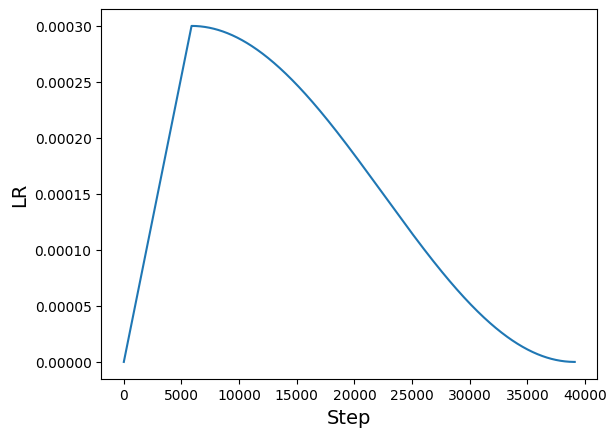

In [33]:
total_steps = int((len(X_train) / BATCH_SIZE) * EPOCHS)
warmup_epoch_percentage = 0.15
warmup_steps = int(total_steps * warmup_epoch_percentage)
scheduled_lrs = WarmUpCosine(
    base_lr=LEARNING_RATE,
    total_steps=total_steps,
    warmup_steps=warmup_steps,
)

lrs = [scheduled_lrs(step) for step in range(total_steps)]
plt.plot(lrs)
plt.xlabel("Step", fontsize=14)
plt.ylabel("LR", fontsize=14)
plt.show()

# Assemble the callbacks.
train_callbacks = [TrainMonitor(epoch_interval=5)]

In [34]:
# Check everything matches
print("="*50)
print("ARCHITECTURE CHECK:")
print(f"IMAGE_SIZE: {IMAGE_SIZE}")
print(f"PATCH_SIZE: {PATCH_SIZE}")
print(f"PATCH_AREA: {PATCH_AREA}")
print(f"Expected: {PATCH_SIZE * PATCH_SIZE * 3}")
print()
print("DATA CHECK:")
print(f"DeepLense shape: {deeplense_images.shape}")
print(f"Min/Max: {deeplense_images.min():.3f} / {deeplense_images.max():.3f}")
print(f"Expected: (N, 48, 48, 3) with range [0,1]")
print("="*50)

ARCHITECTURE CHECK:
IMAGE_SIZE: 48
PATCH_SIZE: 4
PATCH_AREA: 48
Expected: 48

DATA CHECK:


NameError: name 'deeplense_images' is not defined

In [ ]:
optimizer = keras.optimizers.AdamW(
    learning_rate=scheduled_lrs, weight_decay=WEIGHT_DECAY
)

# Create a tf.data.Dataset for training images
train_ds = (
    tf.data.Dataset.from_tensor_slices(X_train)
    .map(load_and_preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

# For the validation data, we'll use 'test_ds' that was already defined
val_ds = test_ds # Renaming for clarity if needed, but test_ds serves as validation data

# Compile and pretrain the model.
mae_model.compile(
    optimizer=optimizer, loss=keras.losses.MeanSquaredError(), metrics=["mae"]
)
history = mae_model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=train_callbacks,
)

# Measure its performance.
loss, mae = mae_model.evaluate(test_ds)
print(f"Loss: {loss:.2f}")
print(f"MAE: {mae:.2f}")

In [ ]:
encoder.save_weights("/kaggle/working/mae_encoder_pretrained.weights.h5")
print("saved weights")

MAE pretraining was stopped early to avoid overfitting to dominant luminous structures and preserve generalizable representations for downstream physics-informed fine-tuning

***PHASE 3 - FINE TUNING***

In [35]:
encoder.load_weights(
    "/kaggle/input/models/sqyhu80/finalpretrainedencoder/tensorflow2/default/1/mae_encoder_pretrained.weights.h5"
) 

In [36]:

print("Encoder weights loaded!")
print("   Pre-trained on: CIFAR-100 (colors, shapes, patterns)")
print("   Adapted on: DeepLense (50K galaxy images)")
print("   Ready for: Classification on 1K labeled images")

Encoder weights loaded!
   Pre-trained on: CIFAR-100 (colors, shapes, patterns)
   Adapted on: DeepLense (50K galaxy images)
   Ready for: Classification on 1K labeled images


In [39]:
# SAMPLE 1000 LABELED IMAGES (500 + 500)

import numpy as np

# Use YOUR variable names: lenses_paths and non_lenses_paths
np.random.seed(42)
selected_lens = np.random.choice(lenses_paths, size=500, replace=False)
selected_nonlens = np.random.choice(non_lenses_paths, size=500, replace=False)

# Combine
finetune_paths = list(selected_lens) + list(selected_nonlens)
finetune_labels = [1] * 500 + [0] * 500  # 1 = Lens, 0 = Non-Lens

# Shuffle
shuffle_idx = np.random.permutation(1000)
finetune_paths = [finetune_paths[i] for i in shuffle_idx]
finetune_labels = [finetune_labels[i] for i in shuffle_idx]

print("  Dataset sampled!")
print(f"   Total images: {len(finetune_paths)}")
print(f"   Lenses: {sum(finetune_labels)}")
print(f"   Non-lenses: {1000 - sum(finetune_labels)}")

  Dataset sampled!
   Total images: 1000
   Lenses: 500
   Non-lenses: 500


In [40]:
# ============================================
# LOAD 1K IMAGES INTO MEMORY
# ============================================
import matplotlib.pyplot as plt

def load_images_for_classification(paths, target_size=48):
    """Load .npy images and preprocess"""
    images = []
    
    print(f"Loading {len(paths)} images...")
    
    for i, path in enumerate(paths):
        if (i + 1) % 200 == 0:
            print(f"  Progress: {i+1}/{len(paths)}")
        
        try:
            # Load .npy file
            img = np.load(path)
            
            # Handle (C, H, W) -> (H, W, C)
            if img.shape[0] == 3 and len(img.shape) == 3:
                img = np.transpose(img, (1, 2, 0))
            
            # Handle 2D grayscale
            if len(img.shape) == 2:
                img = np.stack([img, img, img], axis=-1)
            elif img.shape[-1] == 1:
                img = np.repeat(img, 3, axis=-1)
            
            # Resize to 48x48
            img_resized = tf.image.resize(img, (target_size, target_size)).numpy()
            
            # Normalize to [0, 1]
            img_min = img_resized.min()
            img_max = img_resized.max()
            img_normalized = (img_resized - img_min) / (img_max - img_min + 1e-8)
            
            images.append(img_normalized)
            
        except Exception as e:
            print(f"  ⚠️ Error loading {path}: {e}")
            continue
    
    return np.array(images, dtype='float32')

# Load images
X_finetune = load_images_for_classification(finetune_paths, target_size=IMAGE_SIZE)
y_finetune = np.array(finetune_labels, dtype='int32')

print(f"\n✅ Images loaded!")
print(f"   Shape: {X_finetune.shape}")
print(f"   Labels: {y_finetune.shape}")
print(f"   Range: [{X_finetune.min():.3f}, {X_finetune.max():.3f}]")

Loading 1000 images...
  Progress: 200/1000
  Progress: 400/1000
  Progress: 600/1000
  Progress: 800/1000
  Progress: 1000/1000

✅ Images loaded!
   Shape: (1000, 48, 48, 3)
   Labels: (1000,)
   Range: [0.000, 1.000]


In [42]:
# SPLITING INTO TRAIN/VALIDATION

from sklearn.model_selection import train_test_split

X_train_ft, X_val_ft, y_train_ft, y_val_ft = train_test_split(
    X_finetune, 
    y_finetune,
    test_size=0.2,
    random_state=42,
    stratify=y_finetune
)

print("  Split complete!")
print(f"\n   Training: {len(X_train_ft)} images")
print(f"     - Lenses: {sum(y_train_ft)}")
print(f"     - Non-lenses: {len(y_train_ft) - sum(y_train_ft)}")
print(f"\n   Validation: {len(X_val_ft)} images")
print(f"     - Lenses: {sum(y_val_ft)}")
print(f"     - Non-lenses: {len(y_val_ft) - sum(y_val_ft)}")

  Split complete!

   Training: 800 images
     - Lenses: 400
     - Non-lenses: 400

   Validation: 200 images
     - Lenses: 100
     - Non-lenses: 100


In [45]:
# ============================================
# BUILD CLASSIFIER (FIXED!)
# ============================================

# FREEZE the encoder (recommended for 1K images)
encoder.trainable = False

print(f"Encoder trainable: {encoder.trainable}")
print(f"Encoder params: {encoder.count_params():,}")

# Build classifier
inputs = keras.Input(shape=(IMAGE_SIZE, IMAGE_SIZE, 3), name='input_image')

# Use YOUR existing patch_layer
patches = patch_layer(inputs)

# 🔥 CREATE NEW PATCH ENCODER FOR DOWNSTREAM (NO MASKING!)
patch_encoder_downstream = PatchEncoder(
    patch_size=PATCH_SIZE,
    projection_dim=ENC_PROJ_DIM,
    mask_proportion=0.0,  # No masking!
    downstream=True       # 🔥 THIS IS KEY!
)

# Get embeddings (single output, no masking)
patch_embeddings = patch_encoder_downstream(patches)

# Pass through frozen encoder
encoded = encoder(patch_embeddings)

# Global pooling
x = layers.GlobalAveragePooling1D(name='global_pool')(encoded)

# Classification head
x = layers.Dense(256, activation='relu', name='fc1')(x)
x = layers.Dropout(0.3, name='dropout1')(x)
x = layers.Dense(128, activation='relu', name='fc2')(x)
x = layers.Dropout(0.3, name='dropout2')(x)

# Binary output
outputs = layers.Dense(1, activation='sigmoid', name='output')(x)

# Create model
classifier = keras.Model(inputs=inputs, outputs=outputs, name='lens_classifier')

print("\n✅ Classifier built!")
print(f"   Architecture: 48×48×3 → Encoder → 256 → 128 → 1")

classifier.summary()

Encoder trainable: False
Encoder params: 445,248

✅ Classifier built!
   Architecture: 48×48×3 → Encoder → 256 → 128 → 1


Model: "lens_classifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 48, 48, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patches (Patches)               │ (None, 144, 48)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ patch_encoder_1 (PatchEncoder)  │ (None, 144, 192)       │        37,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mae_enc_strong (Functional)     │ (None, 144, 192)       │       445,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_pool                     │ (None, 192)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc1 (Dense)                     │ (None, 256)            │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout1 (Dropout)              │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ fc2 (Dense)                     │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout2 (Dropout)              │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 564,737 (2.15 MB)

 Trainable params: 119,489 (466.75 KB)

 Non-trainable params: 445,248 (1.70 MB)

In [47]:
# ============================================
# COMPILE MODEL
# ============================================

classifier.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall'),
        keras.metrics.AUC(name='auc')
    ]
)

print("   Model compiled!")
print("   Optimizer: Adam (lr=0.001)")
print("   Loss: Binary cross-entropy")
print("   Metrics: Accuracy, Precision, Recall, AUC")

   Model compiled!
   Optimizer: Adam (lr=0.001)
   Loss: Binary cross-entropy
   Metrics: Accuracy, Precision, Recall, AUC


In [48]:
# ============================================
# SETUP CALLBACKS
# ============================================

early_stop = keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    verbose=1
)

checkpoint = keras.callbacks.ModelCheckpoint(
    'best_classifier.weights.h5',
    monitor='val_accuracy',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr, checkpoint]

print("✅ Callbacks configured!")

✅ Callbacks configured!


In [51]:
# ============================================
# TRAIN CLASSIFIER
# ============================================

print("="*60)
print(" STARTING FINE-TUNING")
print("="*60)
print(f"   Training: {len(X_train_ft)} images")
print(f"   Validation: {len(X_val_ft)} images")
print(f"   Batch size: 32")
print(f"   Max epochs: 50")
print("="*60)

history_ft = classifier.fit(
    X_train_ft, 
    y_train_ft,
    validation_data=(X_val_ft, y_val_ft),
    epochs=60,
    batch_size=32,
    callbacks=callbacks_list,
    verbose=1
)

print("\n" + "="*60)
print(" TRAINING COMPLETE!")
print("="*60)

 STARTING FINE-TUNING
   Training: 800 images
   Validation: 200 images
   Batch size: 32
   Max epochs: 50
Epoch 1/60
23/25 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8646 - auc: 0.9030 - loss: 0.3842 - precision: 0.8813 - recall: 0.8556
Epoch 1: val_accuracy did not improve from 0.90500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8646 - auc: 0.9047 - loss: 0.3815 - precision: 0.8799 - recall: 0.8560 - val_accuracy: 0.9000 - val_auc: 0.9499 - val_loss: 0.2961 - val_precision: 0.9167 - val_recall: 0.8800 - learning_rate: 5.0000e-04
Epoch 2/60
21/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8696 - auc: 0.9352 - loss: 0.3182 - precision: 0.8892 - recall: 0.8577
Epoch 2: val_accuracy did not improve from 0.90500
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.8696 - auc: 0.9345 - loss: 0.3197 - precision: 0.8864 - recall: 0.8591 - val_accuracy: 0.9050 - val_auc: 0.9491 - val_loss: 0.2978 - val_precision: 0.9175 - val_recall: 0.8900 - learning_rate: 5.0000e-04
Ep

In [52]:
# ============================================
# EVALUATE PERFORMANCE
# ============================================

# Predictions
y_pred_proba = classifier.predict(X_val_ft, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

# Evaluate
val_loss, val_acc, val_prec, val_rec, val_auc = classifier.evaluate(
    X_val_ft, y_val_ft, verbose=0
)

print("="*60)
print("  VALIDATION RESULTS")
print("="*60)
print(f"   Accuracy:  {val_acc*100:.2f}%")
print(f"   Precision: {val_prec*100:.2f}%")
print(f"   Recall:    {val_rec*100:.2f}%")
print(f"   AUC:       {val_auc:.4f}")
print("="*60)

# Confusion matrix
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_val_ft, y_pred)
print("\n  Confusion Matrix:")
print("              Predicted")
print("              Non-Lens  Lens")
print(f"True Non-Lens    {cm[0,0]:3d}     {cm[0,1]:3d}")
print(f"True Lens        {cm[1,0]:3d}     {cm[1,1]:3d}")

print("\n  Classification Report:")
print(classification_report(y_val_ft, y_pred, target_names=['Non-Lens', 'Lens']))

# Success check
print("\n  Success Criteria:")
if val_acc >= 0.80:
    print("     EXCELLENT! Accuracy ≥ 80%")
    print("   → Ready for physics loss!")
elif val_acc >= 0.75:
    print("     GOOD! Accuracy ≥ 75%")
    print("   → Can proceed to physics loss")
elif val_acc >= 0.70:
    print("     MODERATE. Accuracy ≥ 70%")
else:
    print("     LOW. Accuracy < 70%")

  VALIDATION RESULTS
   Accuracy:  91.00%
   Precision: 92.71%
   Recall:    89.00%
   AUC:       0.9552

  Confusion Matrix:
              Predicted
              Non-Lens  Lens
True Non-Lens     93       7
True Lens         11      89

  Classification Report:
              precision    recall  f1-score   support

    Non-Lens       0.89      0.93      0.91       100
        Lens       0.93      0.89      0.91       100

    accuracy                           0.91       200
   macro avg       0.91      0.91      0.91       200
weighted avg       0.91      0.91      0.91       200


  Success Criteria:
     EXCELLENT! Accuracy ≥ 80%
   → Ready for physics loss!


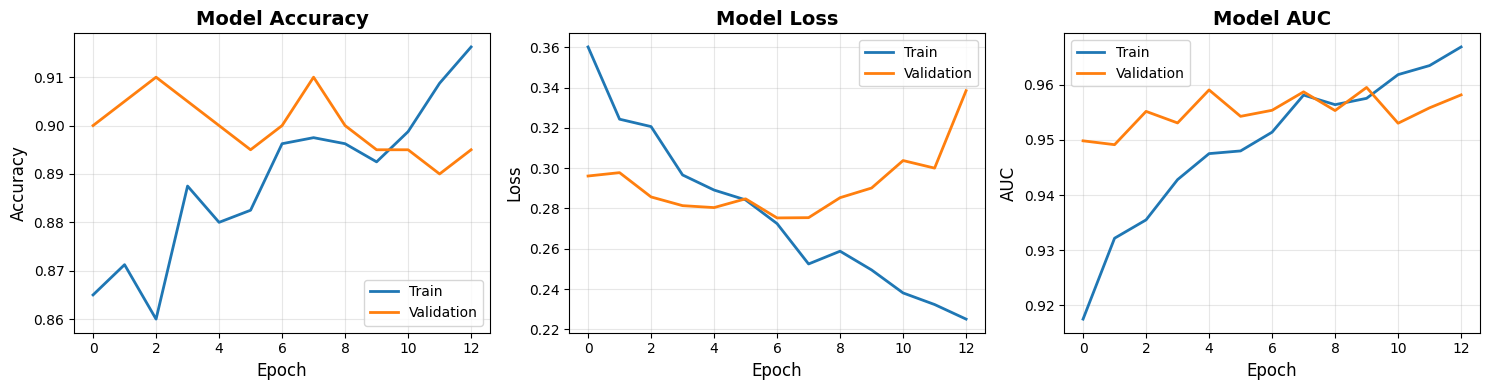

  Training curves saved!


In [54]:
# ============================================
# PLOT TRAINING CURVES
# ============================================

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Accuracy
axes[0].plot(history_ft.history['accuracy'], label='Train', linewidth=2)
axes[0].plot(history_ft.history['val_accuracy'], label='Validation', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Accuracy', fontsize=12)
axes[0].set_title('Model Accuracy', fontsize=14, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Loss
axes[1].plot(history_ft.history['loss'], label='Train', linewidth=2)
axes[1].plot(history_ft.history['val_loss'], label='Validation', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Loss', fontsize=12)
axes[1].set_title('Model Loss', fontsize=14, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# AUC
axes[2].plot(history_ft.history['auc'], label='Train', linewidth=2)
axes[2].plot(history_ft.history['val_auc'], label='Validation', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('AUC', fontsize=12)
axes[2].set_title('Model AUC', fontsize=14, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

print("  Training curves saved!")

In [55]:
# ============================================
# SAVE TRAINED MODEL
# ============================================

classifier.save_weights('lens_classifier_finetuned.weights.h5')
classifier.save('lens_classifier_full.keras')
encoder.save_weights('encoder_after_finetuning.weights.h5')

print("  Models saved!")
print("\n   Files created:")
print("     1. lens_classifier_finetuned.weights.h5")
print("     2. lens_classifier_full.keras")
print("     3. encoder_after_finetuning.weights.h5")
print("\n   Next: Physics loss (if accuracy > 75%)")

  Models saved!

   Files created:
     1. lens_classifier_finetuned.weights.h5
     2. lens_classifier_full.keras
     3. encoder_after_finetuning.weights.h5

   Next: Physics loss (if accuracy > 75%)


In [57]:
# ============================================
# FORCE DOWNLOAD WITH BUTTON
# ============================================
from google.colab import files
import os

# This works in Kaggle too!
files_to_download = [
    'lens_classifier_finetuned.weights.h5',
    'lens_classifier_full.keras', 
    'encoder_after_finetuning.weights.h5'
]

for filename in files_to_download:
    filepath = f'/kaggle/working/{filename}'
    if os.path.exists(filepath):
        print(f"📥 Downloading {filename}...")
        try:
            files.download(filepath)
            print(f"✅ {filename} downloaded!")
        except:
            print(f"⚠️ Download via Output panel after saving version")
    else:
        print(f"❌ {filename} not found!")

📥 Downloading lens_classifier_finetuned.weights.h5...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ lens_classifier_finetuned.weights.h5 downloaded!
📥 Downloading lens_classifier_full.keras...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ lens_classifier_full.keras downloaded!
📥 Downloading encoder_after_finetuning.weights.h5...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ encoder_after_finetuning.weights.h5 downloaded!
